In [1]:
import os
import gc
import json
import time
import random
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset
from collections import Counter

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Torch :", torch.__version__)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))

os.makedirs("../results/models", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

Device: cuda
Torch : 2.14.0+cu126
GPU   : NVIDIA GeForce RTX 2050


In [2]:
# ============================================================
# B2: PHONE HOLDOUT SPLIT
# ============================================================
train_df = pd.read_csv("../data/processed/train_hard3.csv")
test_df  = pd.read_csv("../data/processed/test_hard3.csv")

print("=" * 60)
print("DATASET — B2 (Phone Holdout)")
print("=" * 60)
print(f"Train: {train_df.shape}")
print(f"Test : {test_df.shape}")

labels = sorted(train_df["label"].unique().tolist())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print(f"\nLabels: {label2id}")
print(f"\nTrain dist:\n{train_df['label'].value_counts()}")
print(f"\nTest dist:\n{test_df['label'].value_counts()}")

DATASET — B2 (Phone Holdout)
Train: (4162, 6)
Test : (2843, 6)

Labels: {'normal': 0, 'promo': 1, 'smish': 2}

Train dist:
label
normal    1990
promo     1366
smish      806
Name: count, dtype: int64

Test dist:
label
smish     2003
normal     498
promo      342
Name: count, dtype: int64


In [3]:
t0 = time.time()

# ---------- 3.1: Cluster ----------
vec_campaign = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 6),
    max_features=20000, min_df=2, sublinear_tf=True,
)
X_campaign = vec_campaign.fit_transform(train_df["text_clean"].astype(str))

kmeans = KMeans(n_clusters=150, random_state=SEED, n_init=10)
train_df = train_df.copy()
train_df["cluster"] = kmeans.fit_predict(X_campaign)

print(f"[{time.time()-t0:.1f}s] Clusters: {train_df['cluster'].nunique()}")

# ---------- 3.2: Split ----------
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss.split(train_df, groups=train_df["cluster"]))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split   = train_df.iloc[val_idx].reset_index(drop=True)

print(f"\n{'='*60}")
print("CAMPAIGN-AWARE SPLIT")
print("=" * 60)
print(f"Train: {train_split.shape}")
print(f"Val  : {val_split.shape}")
print(f"Cluster overlap: {len(set(train_split['cluster']) & set(val_split['cluster']))}")

# ---------- 3.3: Strict Vectorized Near-Dup Filter ----------
print(f"\n[{time.time()-t0:.1f}s] Strict near-duplicate filter...")

vec_word = TfidfVectorizer(analyzer='word', ngram_range=(1, 3),
                            min_df=2, max_features=15000, sublinear_tf=True)
vec_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                            min_df=2, max_features=15000, sublinear_tf=True)

X_train_w = vec_word.fit_transform(train_split["text_clean"].astype(str))
X_val_w   = vec_word.transform(val_split["text_clean"].astype(str))
X_train_c = vec_char.fit_transform(train_split["text_clean"].astype(str))
X_val_c   = vec_char.transform(val_split["text_clean"].astype(str))

sim_w = cosine_similarity(X_val_w, X_train_w).max(axis=1)
sim_c = cosine_similarity(X_val_c, X_train_c).max(axis=1)

keep_mask = (sim_w < 0.55) & (sim_c < 0.80)
val_split_clean = val_split[keep_mask].reset_index(drop=True)

print(f"\nVal before filter: {len(val_split)}")
print(f"Val after filter : {len(val_split_clean)}")
print(f"Removed          : {len(val_split) - len(val_split_clean)}")

# ---------- 3.4: Final Verify ----------
X_check = vec_word.transform(val_split_clean["text_clean"].astype(str).head(200))
sim_check = cosine_similarity(X_check, X_train_w).max(axis=1)
near_dup_count = (sim_check > 0.60).sum()

print(f"\nNear-duplicates (first 200): {near_dup_count}")
print("✅ Clean" if near_dup_count <= 5 else "⚠️ Still leaky")
print(f"\n[{time.time()-t0:.1f}s] Cell 3 complete!")

[52.0s] Clusters: 150

CAMPAIGN-AWARE SPLIT
Train: (3552, 7)
Val  : (610, 7)
Cluster overlap: 0

[52.0s] Strict near-duplicate filter...

Val before filter: 610
Val after filter : 432
Removed          : 178

Near-duplicates (first 200): 0
✅ Clean

[52.9s] Cell 3 complete!


In [4]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocab: {tokenizer.vocab_size}")
print("✅ Tokenizer ready")

Vocab: 250002
✅ Tokenizer ready


In [5]:
random.seed(SEED)

def augment(text):
    if "[URL]" in text and random.random() < 0.5:
        text = text.replace("[URL]", "").strip()
    if "[PHONE]" in text and random.random() < 0.5:
        text = text.replace("[PHONE]", "").strip()
    words = text.split()
    if len(words) > 5 and random.random() < 0.2:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
        text = " ".join(words)
    return text

aug_rows = []
for _, row in train_split.iterrows():
    for _ in range(2):
        new_row = row.copy()
        new_text = augment(row["text_clean"])
        if new_text != row["text_clean"]:
            new_row["text_clean"] = new_text
            aug_rows.append(new_row)

if aug_rows:
    train_aug = pd.concat(
        [train_split, pd.DataFrame(aug_rows)], ignore_index=True
    ).sample(frac=1, random_state=SEED).reset_index(drop=True)
else:
    train_aug = train_split

print(f"Original train : {train_split.shape}")
print(f"Augmented train: {train_aug.shape}")
print(f"Added rows     : {len(aug_rows)}")

smish_aug = train_aug[train_aug["label"] == "smish"]
smish_no_phone = smish_aug[~smish_aug["text_clean"].str.contains(r"\[PHONE\]", regex=True)]
print(f"\nSmish WITHOUT phone: {len(smish_no_phone)}  ← B2-এর main goal")

Original train : (3552, 7)
Augmented train: (5597, 7)
Added rows     : 2045

Smish WITHOUT phone: 677  ← B2-এর main goal


In [6]:
MAX_LEN = 128

class SMSDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=128):
        self.texts = df["text_clean"].astype(str).tolist()
        self.labels = [label2id[l] for l in df["label"]]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len,
            return_tensors=None,
        )
        enc["labels"] = self.labels[idx]
        return enc

train_ds = SMSDataset(train_aug, tokenizer, label2id, MAX_LEN)
val_ds   = SMSDataset(val_split_clean, tokenizer, label2id, MAX_LEN)
test_ds  = SMSDataset(test_df, tokenizer, label2id, MAX_LEN)

print(f"Train: {len(train_ds)}")
print(f"Val  : {len(val_ds)}")
print(f"Test : {len(test_ds)}")

Train: 5597
Val  : 432
Test : 2843


In [7]:
label_counts = Counter(train_aug["label"].map(label2id))
total = sum(label_counts.values())
num_classes = len(labels)
class_weights = {i: total / (num_classes * label_counts[i]) for i in range(num_classes)}
print("Label counts :", dict(label_counts))
print("Class weights:", class_weights)

Label counts : {2: 1535, 1: 1605, 0: 2457}
Class weights: {0: 0.759327092660426, 1: 1.1624091381100727, 2: 1.2154180238870793}


In [8]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(labels),
    id2label=id2label, label2id=label2id
)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16, lora_alpha=32, lora_dropout=0.2, bias="none",
    target_modules=["query", "key", "value", "dense"]
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 3,247,107 || all params: 281,293,062 || trainable%: 1.1544


In [9]:
def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        y = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight_tensor = torch.tensor(
            [self.class_weights[i] for i in range(len(self.class_weights))],
            device=logits.device, dtype=torch.float32,
        )
        loss = nn.CrossEntropyLoss(weight=weight_tensor)(logits, y)
        return (loss, outputs) if return_outputs else loss


training_args = TrainingArguments(
    output_dir="../results/models/lora_b2_final",      # ← b2 (b1 নয়)
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    weight_decay=0.05,
    warmup_steps=0.2,
    max_grad_norm=0.5,
    label_smoothing_factor=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2, early_stopping_threshold=0.001
    )],
)

print("Trainer ready ✅")
print("Train:", len(trainer.train_dataset), "| Eval:", len(trainer.eval_dataset))

Trainer ready ✅
Train: 5597 | Eval: 432


In [10]:
sample_eval = trainer.evaluate(val_ds, metric_key_prefix="eval")
f1_keys = [k for k in sample_eval.keys() if "f1" in k]
print(f"F1 keys available: {f1_keys}")
print(f"metric_for_best_model: {trainer.args.metric_for_best_model}")

if trainer.args.metric_for_best_model not in sample_eval:
    print("⚠️ Fixing...")
    if "eval_macro_f1" in sample_eval:
        trainer.args.metric_for_best_model = "eval_macro_f1"
    print(f"→ {trainer.args.metric_for_best_model}")
else:
    print("✅ MATCH")

Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
No log,1.188831,0,0.137255,0.259259


F1 keys available: ['eval_macro_f1']
metric_for_best_model: eval_macro_f1
✅ MATCH


In [11]:
train_result = trainer.train()
print("\n✅ Training done")
print(train_result)

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.009023,0.235881,0.866548,0.918981
2,0.368570,0.109578,0.946600,0.967593
3,0.295216,0.085506,0.971005,0.981481
4,0.234993,0.069206,0.972053,0.981481
5,0.199865,0.084022,0.958830,0.972222



✅ Training done
TrainOutput(global_step=1750, training_loss=0.6178121386936732, metrics={'train_runtime': 632.8953, 'train_samples_per_second': 44.217, 'train_steps_per_second': 2.765, 'total_flos': 1910595631034880.0, 'train_loss': 0.6178121386936732, 'epoch': 5.0})


In [12]:
print("=" * 60)
print("B2 TEST EVALUATION (Phone Holdout, OOD)")
print("=" * 60)

test_results = trainer.evaluate(test_ds, metric_key_prefix="test")
print(f"Test Accuracy : {test_results['test_accuracy']:.4f}")
print(f"Test Macro F1 : {test_results['test_macro_f1']:.4f}")

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=labels))

smish_idx = label2id["smish"]
smish_mask = y_true == smish_idx
smish_recall = (y_pred[smish_mask] == smish_idx).mean()
smish_precision = (y_true[y_pred == smish_idx] == smish_idx).mean()

print(f"\n>>> SMISH RECALL   : {smish_recall:.4f} <<<")
print(f">>> SMISH PRECISION: {smish_precision:.4f} <<<")

B2 TEST EVALUATION (Phone Holdout, OOD)


[transformers] early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.199865,1.363572,5,0.760265,0.787197


Test Accuracy : 0.7872
Test Macro F1 : 0.7603



CLASSIFICATION REPORT
              precision    recall  f1-score   support

      normal       0.78      0.99      0.88       498
       promo       0.42      0.95      0.58       342
       smish       0.99      0.71      0.83      2003

    accuracy                           0.79      2843
   macro avg       0.73      0.88      0.76      2843
weighted avg       0.88      0.79      0.80      2843


>>> SMISH RECALL   : 0.7089 <<<
>>> SMISH PRECISION: 0.9889 <<<


In [13]:
def build_baseline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ])

baseline = build_baseline()
baseline.fit(train_df["text_clean"], train_df["label"])
baseline_pred = baseline.predict(test_df["text_clean"])
baseline_f1 = f1_score(test_df["label"], baseline_pred, average="macro")

lora_f1 = test_results["test_macro_f1"]

print("=" * 60)
print("B2: BASELINE vs LoRA")
print("=" * 60)
print(f"Baseline (TF-IDF+LR) : {baseline_f1:.4f}")
print(f"LoRA (XLM-R)         : {lora_f1:.4f}")
print(f"Improvement          : {lora_f1 - baseline_f1:+.4f} ({(lora_f1-baseline_f1)/baseline_f1*100:+.1f}%)")

B2: BASELINE vs LoRA
Baseline (TF-IDF+LR) : 0.5329
LoRA (XLM-R)         : 0.7603
Improvement          : +0.2274 (+42.7%)


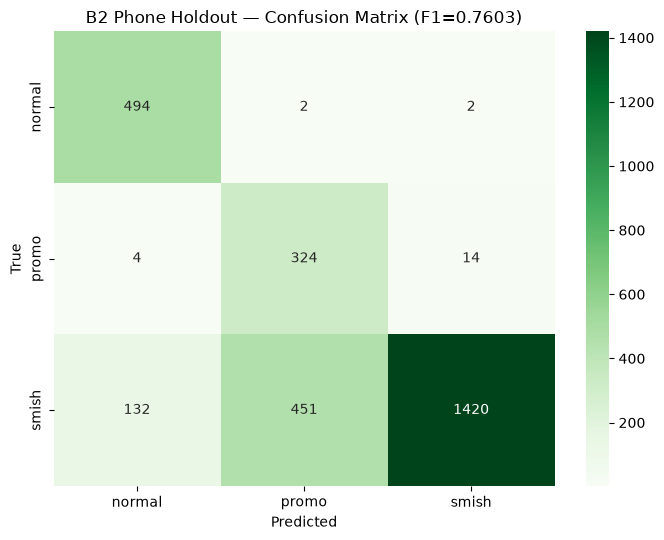

✅ Saved: confusion_matrix_b2.png


In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'B2 Phone Holdout — Confusion Matrix (F1={lora_f1:.4f})')
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_b2.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix_b2.png")

In [15]:
b2_results = {
    "experiment": "B2_Phone_Holdout",
    "model": "XLM-R + LoRA (r=16)",
    "baseline_f1": float(baseline_f1),
    "lora_test_f1": float(lora_f1),
    "lora_test_accuracy": float(test_results["test_accuracy"]),
    "smish_recall": float(smish_recall),
    "smish_precision": float(smish_precision),
    "improvement": float(lora_f1 - baseline_f1),
    "train_size": len(train_ds),
    "val_size": len(val_ds),
    "test_size": len(test_ds),
}
with open("../results/final_results_b2.json", "w", encoding="utf-8") as f:
    json.dump(b2_results, f, indent=2)

# Model save
trainer.save_model("../results/models/lora_b2_final")
tokenizer.save_pretrained("../results/models/lora_b2_final")

print("✅ Saved: final_results_b2.json + lora_b2_final/")

✅ Saved: final_results_b2.json + lora_b2_final/


In [ ]:
print("=" * 75)
print("FINAL COMPARISON: B1 (URL) vs B2 (Phone)")
print("=" * 75)
print(f"{'Split':22s} | {'Baseline':>10s} | {'LoRA':>10s} | {'Smish Rec':>10s} | {'Improve':>10s}")
print("-" * 75)
print(f"{'B1 (URL Holdout)':22s} | {0.5963:>10.4f} | {0.7463:>10.4f} | {0.5888:>10.4f} | {0.1500:>+10.4f}")
print(f"{'B2 (Phone Holdout)':22s} | {baseline_f1:>10.4f} | {lora_f1:>10.4f} | {smish_recall:>10.4f} | {lora_f1-baseline_f1:>+10.4f}")
print("=" * 75)

FINAL COMPARISON: B1 (URL) vs B2 (Phone)
Split                  |   Baseline |       LoRA |  Smish Rec |    Improve
---------------------------------------------------------------------------
B1 (URL Holdout)       |     0.5963 |     0.7463 |     0.5888 |    +0.1500
B2 (Phone Holdout)     |     0.5329 |     0.7603 |     0.7089 |    +0.2274


: 